In [96]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder,LabelEncoder
from sklearn.metrics import f1_score,accuracy_score,classification_report,confusion_matrix

In [97]:
df = pd.read_csv("shop_smart_ecommerce.csv")

Text(0.5, 1.0, 'Visitor made purchase or not')

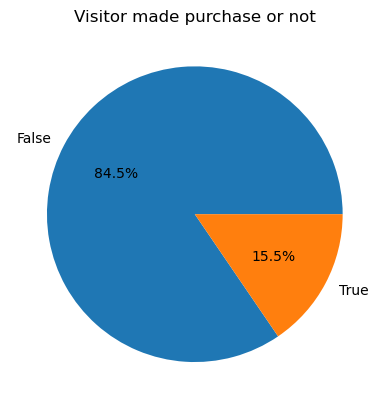

In [98]:
class_count = df["Revenue"].value_counts()
plt.pie(class_count,labels = ["False","True"],autopct="%1.1f%%")
plt.title("Visitor made purchase or not")

In [99]:
df

,Administrative,Administrative_Duration,Informational,Informational_Duration,ProductRelated,ProductRelated_Duration,BounceRates,ExitRates,PageValues,SpecialDay,Month,OperatingSystems,Browser,Region,TrafficType,VisitorType,Weekend,Revenue
0,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,1,1,1,1,Returning_Visitor,False,False
1,0,0.0,0,0.0,2,64.000000,0.000000,0.100000,0.000000,0.0,Feb,2,2,1,2,Returning_Visitor,False,False
2,0,0.0,0,0.0,1,0.000000,0.200000,0.200000,0.000000,0.0,Feb,4,1,9,3,Returning_Visitor,False,False
3,0,0.0,0,0.0,2,2.666667,0.050000,0.140000,0.000000,0.0,Feb,3,2,2,4,Returning_Visitor,False,False
4,0,0.0,0,0.0,10,627.500000,0.020000,0.050000,0.000000,0.0,Feb,3,3,1,4,Returning_Visitor,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
12325,3,145.0,0,0.0,53,1783.791667,0.007143,0.029031,12.241717,0.0,Dec,4,6,1,1,Returning_Visitor,True,False
12326,0,0.0,0,0.0,5,465.750000,0.000000,0.021333,0.000000,0.0,Nov,3,2,1,8,Returning_Visitor,True,False
12327,0,0.0,0,0.0,6,184.250000,0.083333,0.086667,0.000000,0.0,Nov,3,2,1,13,Returning_Visitor,True,False
12328,4,75.0,0,0.0,15,346.000000,0.000000,0.021053,0.000000,0.0,Nov,2,2,3,11,Returning_Visitor,False,False


<Axes: xlabel='Month', ylabel='Count'>

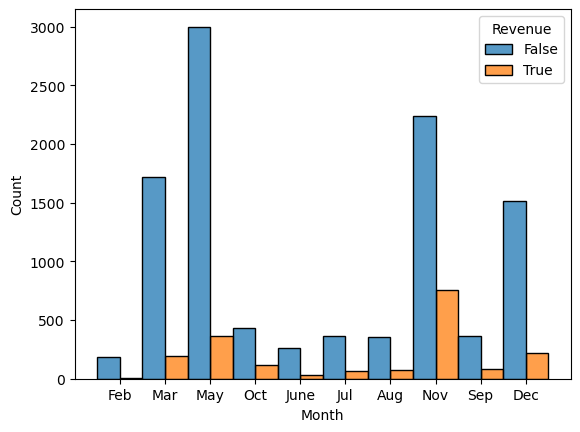

In [100]:
sns.histplot(
    data = df,
    x = "Month",
    hue = "Revenue",
    bins = 12,
    multiple = "dodge"
)

In [101]:
df["Revenue"].value_counts()

Revenue
False    10422
True      1908
Name: count, dtype: int64

<Axes: xlabel='Month', ylabel='Count'>

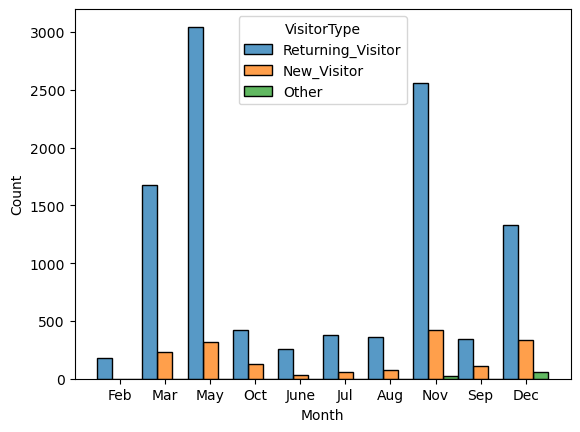

In [102]:
sns.histplot(
    data = df,
    x = "Month",
    hue = "VisitorType",
    bins = 12,
    multiple = "dodge"
)

<Axes: xlabel='Month', ylabel='Count'>

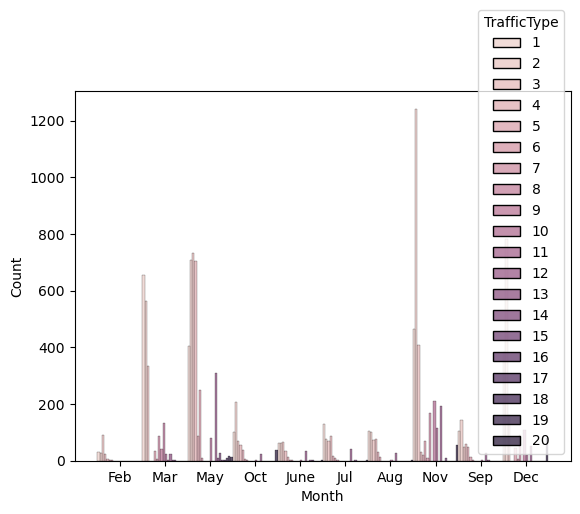

In [103]:
sns.histplot(
    data = df,
    x = "Month",
    hue = "TrafficType",
    bins = 12,
    multiple = "dodge"
)


In [104]:
um_features = X.select_dtypes(include=["int64", "float64"]).columns
cat_features = X.select_dtypes(include=["object", "category"]).columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(handle_unknown="ignore"), cat_features)
    ]
)

In [105]:
X = df.drop("Revenue",axis = 1)
y = df["Revenue"]

In [106]:
X_test , X_train,y_test,y_train = train_test_split(
    X,y,test_size = 0.2,random_state=42
)

In [107]:
from sklearn.tree import DecisionTreeClassifier

max_depths = [3,4,5,6,7,8,9,10]
min_sample_splits = [10,15,20,25,35]
for split in min_sample_splits:
    model = DecisionTreeClassifier(random_state=42,max_depth = 3,min_samples_split = 10)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    print(f"for depth = {split} ,F1 Score : ,{f1_score(y_test,y_pred)}")

for depth = 10 ,F1 Score : ,0.6207391460351632
for depth = 15 ,F1 Score : ,0.6207391460351632
for depth = 20 ,F1 Score : ,0.6207391460351632
for depth = 25 ,F1 Score : ,0.6207391460351632
for depth = 35 ,F1 Score : ,0.6207391460351632


In [108]:
model = DecisionTreeClassifier(random_state=42,max_depth = 3,min_samples_split = 10)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)

trees = []

path = model.cost_complexity_pruning_path(X_train,y_train)
ccp_alphas = path.ccp_alphas

for alpha in ccp_alphas:
    model = DecisionTreeClassifier(random_state=42,max_depth = 3,min_samples_split = 10,ccp_alpha = alpha)
    model.fit(X_train,y_train)
    y_pred = model.predict(X_test)
    trees.append((model,alpha))

best_alpha = 0
best_acc = 0

for model,alpha in trees:
    curr_acc = model.score(X_test,y_test)
    if curr_acc>best_acc:
        best_acc = curr_acc
        best_alpha = alpha

print(best_alpha)
print(best_acc)

0.0
0.8928426601784266


In [110]:
model = DecisionTreeClassifier(random_state=42,max_depth = 3,min_samples_split = 10,ccp_alpha = 0.0)
model.fit(X_train,y_train)
y_pred = model.predict(X_test)
print("F1 Score : ",f1_score(y_test,y_pred))
print(classification_report(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))

F1 Score :  0.6207391460351632
              precision    recall  f1-score   support

           0       0.93      0.95      0.94      8367
           1       0.67      0.58      0.62      1497

    accuracy                           0.89      9864
   macro avg       0.80      0.76      0.78      9864
weighted avg       0.89      0.89      0.89      9864

[[7942  425]
 [ 632  865]]
